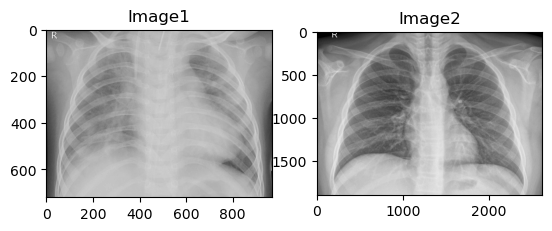

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
# Load two grayscale medical images
img1 = imread('assets/pneumonia3.jpeg', as_gray=True)
img2 = imread('assets/normal2.jpeg', as_gray=True)
plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.title("Image1")
plt.subplot(1,2,2); plt.imshow(img2, cmap='gray'); plt.title("Image2")
plt.show()

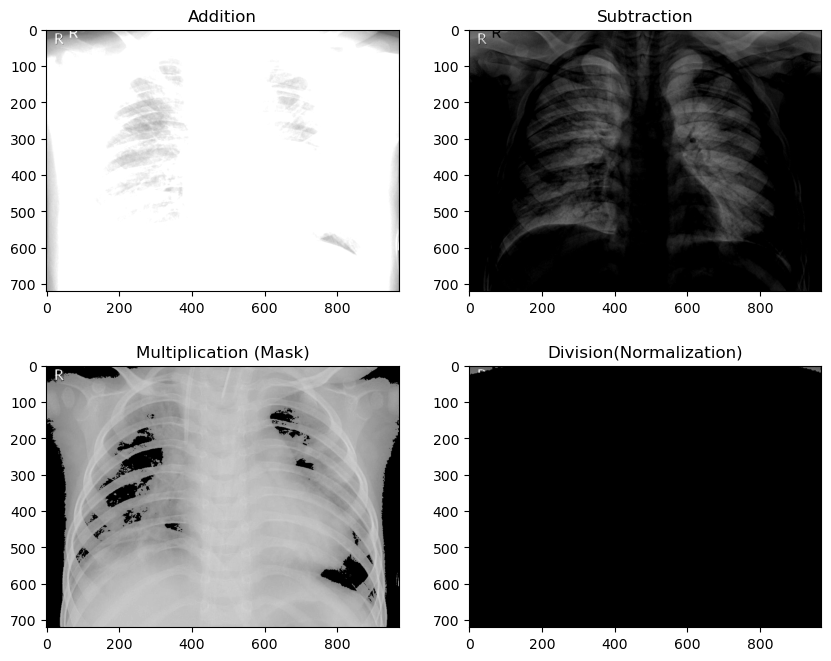

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize

# Load grayscale images
img1 = imread('assets/pneumonia3.jpeg', as_gray=True)
img2 = imread('assets/normal2.jpeg', as_gray=True)

# Resize img2 to match img1
img2_resized = resize(img2, img1.shape, anti_aliasing=True)
epsilon = 1e-5

# Arithmetic operations
img_add = np.clip(img1 + img2_resized , 0, 1) # Addition
img_sub = np.clip(img1 - img2_resized , 0, 1) # Subtraction
mask = (img1 > 0.5).astype(float) # Binary mask
img_mul = img1 * mask # Multiplication (ROIextraction)
img_div = img1 / (img2_resized + epsilon) # Division (Normalization)
# Show results
plt.figure(figsize=(10,8))
plt.subplot(2,2,1); plt.imshow(img_add, cmap='gray');
plt.title("Addition")
plt.subplot(2,2,2); plt.imshow(img_sub, cmap='gray');
plt.title("Subtraction")
plt.subplot(2,2,3); plt.imshow(img_mul, cmap='gray');
plt.title("Multiplication (Mask)")
plt.subplot(2,2,4); plt.imshow(img_div, cmap='gray'); plt.title("Division(Normalization)")
plt.show()

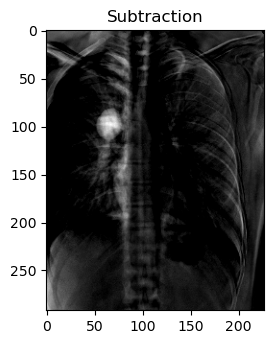

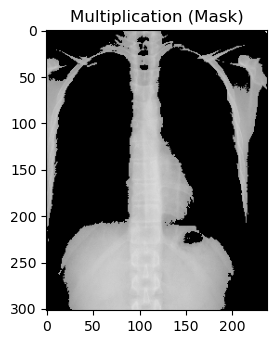

In [40]:
#6. Exercises
#1)
img1 = imread('assets/xray2.png', as_gray=True)
img2 = imread('assets/xray1.png', as_gray=True)

img1_resized = resize(img1, img2.shape, anti_aliasing=True)
img_sub = np.clip(img2 - img1_resized , 0, 1) # Subtraction

plt.figure(figsize=(10,8))
plt.subplot(2,2,2); plt.imshow(img_sub, cmap='gray');
plt.title("Subtraction")
plt.show()

#2)
mask = (img1 > 0.6).astype(float) # Binary mask
img_mul = img1 * mask # Multiplication (ROIextraction)
plt.figure(figsize=(10,8))
plt.subplot(2,2,2); plt.imshow(img_mul, cmap='gray');
plt.title("Multiplication (Mask)")
plt.show()

In [ ]:
!{sys.executable} -m pip install pydicom


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import pydicom
print("Pydicom version:", pydicom.__version__)


Pydicom version: 3.0.1


In [ ]:
import sys
print("Python executable:", sys.executable)

!{sys.executable} -m pip show pydicom


Python executable: d:\Coding\anaconda3\python.exe
Name: pydicom
Version: 3.0.1
Summary: A pure Python package for reading and writing DICOM data
Home-page: 
Author: 
Author-email: Darcy Mason and contributors <darcymason@gmail.com>
License: 
Location: C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages
Requires: 
Required-by: 


DEPRECATION: Loading egg at d:\coding\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


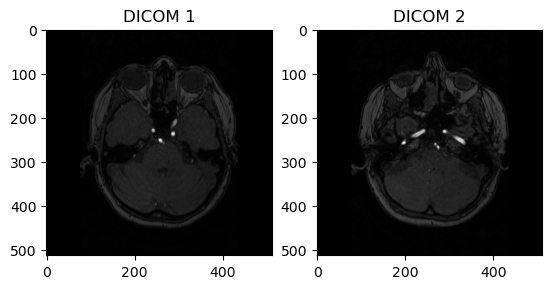

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

# Load DICOM file
ds1 = pydicom.dcmread("assets/1-037.dcm")
ds2 = pydicom.dcmread("assets/1-023.dcm")

# Convert to numpy arrays
img1 = ds1.pixel_array.astype(float)
img2 = ds2.pixel_array.astype(float)

# Normalize (optional, so images are in 0–1 range)
img1 = (img1 - np.min(img1)) / (np.max(img1) - np.min(img1))
img2 = (img2 - np.min(img2)) / (np.max(img2) - np.min(img2))

# Show both images
plt.subplot(1,2,1); plt.imshow(img1, cmap="gray"); plt.title("DICOM 1")
plt.subplot(1,2,2); plt.imshow(img2, cmap="gray"); plt.title("DICOM 2")
plt.show()


4. Discuss a clinical scenario where subtraction imaging is very useful (hint: follow-up
scans for tumors or fractures).

In a certain case when the patient is diagnosed with a brain tumor and the doctor orders a follow-up scan to monitor the tumor's growth.
The first scan is taken as the baseline scan or before treatment, and also state the size and shape of the tumor.
The second scan is taken as the follow-up scan or after treatment/surgery which is to monitor the changes of the tumor.
By applying substraction imaging(second - first scan), we can:
    - Highlight the tumor progression
    - Remove irrelevant background tissue, so the tumor progression is clearer
    - Highlight the changes that might not be obvious by visual inspection alone   

7. Questions for Students
    1. Which operation is most suitable for detecting temporal changes in follow-up medical scans?
    2. Why do we need to add a small value (epsilon) in the division operation?
    3. How can multiplication with a mask be used to focus on a tumor or organ?
    4. What is the main difference in visual effect between substraction and division?

    ------------ANSWERS------------
    1. Substraction is most suitable for detecting temporal changes in follow-up medical scans
    2. So it will not be divided by zero, because they can have same img/pattern. So we add a small constant value to avoid this.
    3. To differenciate the tumor or organ and the other regions, and more focuses on the ROI to be shown. By using binary values, 0-1. We can easily defined the tumor and other regions. 
    4. Addition and substraction have different purposes, additions makes image brighter and enchance overall constrast, since pixel values are combined. Meanwhile substraction is more to highlight differences between two images, useful for detection changes like lesions, fractures, or tumor progression
    4. Subtraction shows the absolute difference in pixel values, making changes appear as brighter or darker spots. Division, on the other hand, emphasizes relative differences, creating contrast where values are proportionally different.